# DeepQBot — Curriculum / Sequential Training

`deepq_vs_all.ipynb` trained a fresh `DeepQBot` round-robin against all 4 existing
brains from episode 1 and never escaped a Q-value collapse (see that notebook's
"Post-mortem" section) — its policy net converged to predicting almost the same
value for every state/action, likely because the round-robin opponent cycle is a
non-stationary target for a single `Q(s,a)`, on top of the usual sparse-reward /
1-step-TD credit-assignment problem.

This notebook tries curriculum learning instead: train against a single,
predictable opponent (`ChaserBot`) for the first 1000 episodes so the network can
discover *some* action-dependent Q-differences in a stationary environment, then
gradually phase in the other 3 opponents (`RandomBot`, `SmeshBot`, frozen
`QTableBot`) over the remaining 1000 episodes to avoid catastrophic forgetting from
an abrupt distribution shift.

In [1]:
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from smeshlite.core.match import Match, MatchConfig
from agents.random_bot import RandomBot
from agents.chaser_bot import ChaserBot
from agents.smesh_bot import SmeshBot
from agents.qtable_bot import QTableBot
from agents.deepq_bot import DeepQBot

## Agent design recap

Same `DeepQBot` as `deepq_vs_all.ipynb` (31-dim relative features, tapered 16→8 MLP,
`action_repeat=6`) — see `agents/deepq_bot.py` for the full docstring. The only thing
that changes here is the **opponent curriculum**:

- **Phase 0 (episodes 1-1000)**: `ChaserBot` only.
- **Phase 1 (episodes 1001-1400)**: 70% `ChaserBot`, 30% one of
  `RandomBot` / `SmeshBot` / `QTableBot` (uniform).
- **Phase 2 (episodes 1401-1700)**: 50% `ChaserBot`, 50% one of the other three.
- **Phase 3 (episodes 1701-2000)**: 25% each — full round robin in expectation.

In [2]:
deepq = DeepQBot()
print("device:", deepq.device, "action_repeat:", deepq.action_repeat)

# Frozen baseline: trained Q-table, no further learning during DeepQBot's training.
qtable_opponent = QTableBot(q_table_path="agents/checkpoints/qtable_bot.json", epsilon=0.0, alpha=0.0)

OTHER_CYCLE = [RandomBot, SmeshBot, lambda: qtable_opponent]
OTHER_NAMES = ["RandomBot", "SmeshBot", "QTableBot"]

N_EPISODES = 2000
LOG_EVERY = 100
EPSILON_START = 0.3
EPSILON_END = 0.02

# End-episode of phases 0, 1, 2 (phase 3 runs to N_EPISODES).
PHASE_BOUNDARIES = (1000, 1400, 1700)
# P(ChaserBot) in each phase; the remainder is split uniformly across OTHER_CYCLE.
CHASER_PROB = (1.0, 0.7, 0.5, 0.25)


def epsilon_for(episode: int) -> float:
    """Linear decay from EPSILON_START to EPSILON_END over N_EPISODES."""
    t = min(episode / N_EPISODES, 1.0)
    return EPSILON_START + (EPSILON_END - EPSILON_START) * t


def opponent_for(episode: int):
    """Curriculum: ChaserBot only at first, then gradually mix in the other 3."""
    if episode <= PHASE_BOUNDARIES[0]:
        phase = 0
    elif episode <= PHASE_BOUNDARIES[1]:
        phase = 1
    elif episode <= PHASE_BOUNDARIES[2]:
        phase = 2
    else:
        phase = 3

    if random.random() < CHASER_PROB[phase]:
        return ChaserBot(), "ChaserBot", phase
    idx = random.randrange(len(OTHER_CYCLE))
    return OTHER_CYCLE[idx](), OTHER_NAMES[idx], phase

device: cuda action_repeat: 6


## Training loop

Identical to `deepq_vs_all.ipynb` except the opponent comes from
`opponent_for(episode)` (the curriculum above) instead of a fixed round-robin cycle.
Every `LOG_EVERY` episodes, aggregate the trailing window (overall and per opponent)
and log it to MLflow as a metric step, alongside the current curriculum phase.

In [3]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("deepq_sequential_learning")

history = []
t0 = time.time()

with mlflow.start_run(run_name=f"deepq_seq_{time.strftime('%Y%m%d_%H%M%S')}") as run:
    run_id = run.info.run_id
    mlflow.log_params({
        "alpha": deepq.alpha,
        "gamma": deepq.gamma,
        "dmg_scale": deepq.dmg_scale,
        "ko_reward": deepq.ko_reward,
        "death_penalty": deepq.death_penalty,
        "time_penalty": deepq.time_penalty,
        "action_repeat": deepq.action_repeat,
        "train_every": deepq.train_every,
        "batch_size": deepq.batch_size,
        "target_update_every": deepq.target_update_every,
        "n_actions": DeepQBot.N_ACTIONS,
        "obs_dim": DeepQBot.OBS_DIM,
        "n_episodes": N_EPISODES,
        "log_every": LOG_EVERY,
        "epsilon_start": EPSILON_START,
        "epsilon_end": EPSILON_END,
        "phase_boundaries": ", ".join(str(b) for b in PHASE_BOUNDARIES),
        "chaser_prob": ", ".join(str(p) for p in CHASER_PROB),
        "device": str(deepq.device),
    })

    for episode in range(1, N_EPISODES + 1):
        deepq.epsilon = epsilon_for(episode)
        opponent, opponent_name, phase = opponent_for(episode)

        m = Match(MatchConfig(time_limit=1800))
        m.reset(n_players=2)
        m.set_player_brain(0, deepq)
        m.set_player_brain(1, opponent)

        while not m.done:
            m.tick()

        final_snapshot = (
            m.characters[0].damage_pct, m.characters[0].stocks,
            m.characters[1].damage_pct, m.characters[1].stocks,
        )
        ep_reward = deepq.new_episode(final_snapshot=final_snapshot)

        history.append({
            "episode": episode,
            "opponent": opponent_name,
            "phase": phase,
            "winner": m.winner,
            "frames": m.frame,
            "episode_reward": ep_reward,
            "epsilon": deepq.epsilon,
            "last_loss": deepq.last_loss,
            "buffer_len": len(deepq.replay_buffer),
        })

        if episode % LOG_EVERY == 0:
            recent = pd.DataFrame(history[-LOG_EVERY:])
            metrics = {
                "win_rate": (recent["winner"] == 0).mean(),
                "avg_reward": recent["episode_reward"].mean(),
                "avg_loss": recent["last_loss"].dropna().mean(),
                "epsilon": deepq.epsilon,
                "buffer_len": len(deepq.replay_buffer),
                "phase": phase,
            }
            for opp_name, group in recent.groupby("opponent"):
                metrics[f"win_rate_{opp_name}"] = (group["winner"] == 0).mean()
                metrics[f"avg_reward_{opp_name}"] = group["episode_reward"].mean()
            mlflow.log_metrics(metrics, step=episode)
            print(f"episode {episode:5d} (phase {phase}): win_rate={metrics['win_rate']:.2f} avg_reward={metrics['avg_reward']:+.3f} avg_loss={metrics['avg_loss']:.4f}")

print(f"done in {time.time() - t0:.1f}s")
df = pd.DataFrame(history)
df.tail()

2026/06/12 00:33:08 INFO mlflow.tracking.fluent: Experiment with name 'deepq_sequential_learning' does not exist. Creating a new experiment.


episode   100 (phase 0): win_rate=0.56 avg_reward=+1.147 avg_loss=0.0097
episode   200 (phase 0): win_rate=0.77 avg_reward=+2.119 avg_loss=0.0081
episode   300 (phase 0): win_rate=0.71 avg_reward=+1.779 avg_loss=0.0075
episode   400 (phase 0): win_rate=0.71 avg_reward=+1.642 avg_loss=0.0088
episode   500 (phase 0): win_rate=0.77 avg_reward=+1.543 avg_loss=0.0112
episode   600 (phase 0): win_rate=0.77 avg_reward=+1.474 avg_loss=0.0125
episode   700 (phase 0): win_rate=0.89 avg_reward=+1.798 avg_loss=0.0159
episode   800 (phase 0): win_rate=0.91 avg_reward=+1.960 avg_loss=0.0164
episode   900 (phase 0): win_rate=0.87 avg_reward=+1.843 avg_loss=0.0171
episode  1000 (phase 0): win_rate=0.88 avg_reward=+1.792 avg_loss=0.0169
episode  1100 (phase 1): win_rate=0.70 avg_reward=+0.803 avg_loss=0.0176
episode  1200 (phase 1): win_rate=0.55 avg_reward=+0.398 avg_loss=0.0158
episode  1300 (phase 1): win_rate=0.63 avg_reward=+0.653 avg_loss=0.0119
episode  1400 (phase 1): win_rate=0.70 avg_reward=+

,episode,opponent,phase,winner,frames,episode_reward,epsilon,last_loss,buffer_len
1995,1996,ChaserBot,3,0.0,705,2.160,0.02056,0.007601,50000
1996,1997,SmeshBot,3,1.0,859,-2.440,0.02042,0.004916,50000
1997,1998,SmeshBot,3,1.0,1600,-2.910,0.02028,0.013959,50000
1998,1999,RandomBot,3,1.0,527,-3.000,0.02014,0.013977,50000
1999,2000,QTableBot,3,1.0,1800,-0.815,0.02000,0.003866,50000


## Results

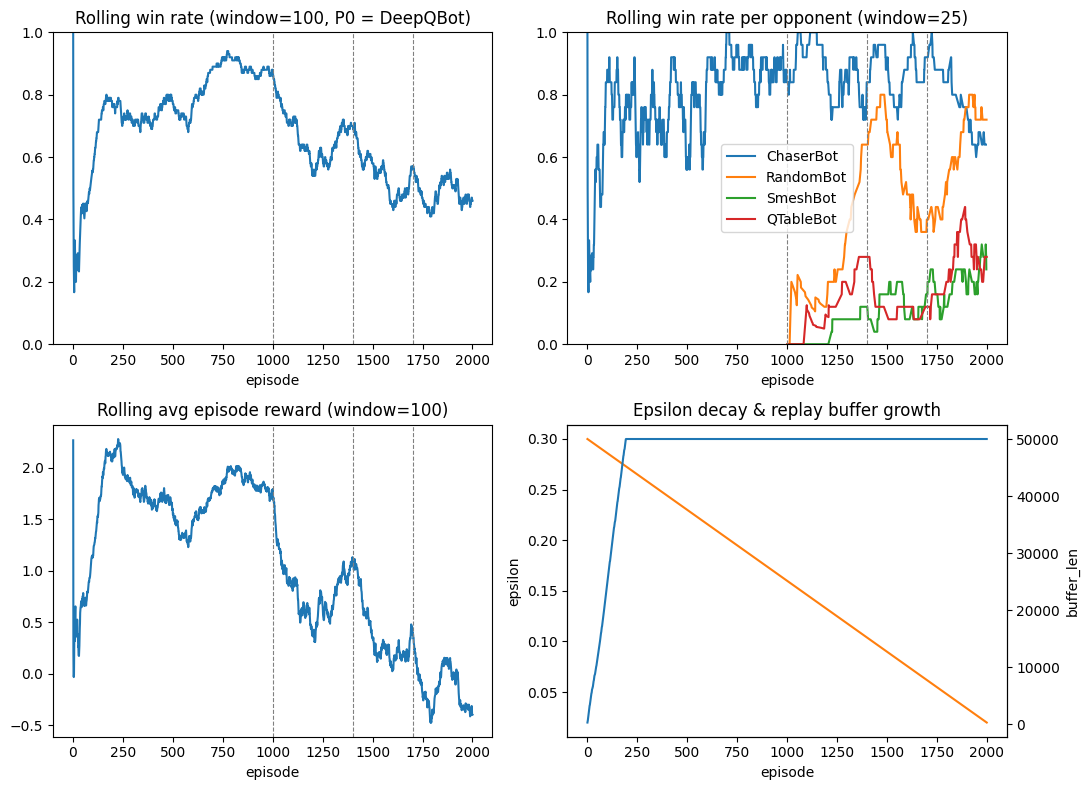

In [4]:
win_rolling = df["winner"].eq(0).rolling(100, min_periods=1).mean()
reward_rolling = df["episode_reward"].rolling(100, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(df["episode"], win_rolling)
for b in PHASE_BOUNDARIES:
    axes[0, 0].axvline(b, color="gray", linestyle="--", linewidth=0.8)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Rolling win rate (window=100, P0 = DeepQBot)")
axes[0, 0].set_xlabel("episode")

for opp_name in ["ChaserBot"] + OTHER_NAMES:
    mask = df["opponent"] == opp_name
    if mask.sum() == 0:
        continue
    opp_win_rolling = df.loc[mask, "winner"].eq(0).rolling(25, min_periods=1).mean()
    axes[0, 1].plot(df.loc[mask, "episode"], opp_win_rolling, label=opp_name)
for b in PHASE_BOUNDARIES:
    axes[0, 1].axvline(b, color="gray", linestyle="--", linewidth=0.8)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Rolling win rate per opponent (window=25)")
axes[0, 1].set_xlabel("episode")
axes[0, 1].legend()

axes[1, 0].plot(df["episode"], reward_rolling)
for b in PHASE_BOUNDARIES:
    axes[1, 0].axvline(b, color="gray", linestyle="--", linewidth=0.8)
axes[1, 0].set_title("Rolling avg episode reward (window=100)")
axes[1, 0].set_xlabel("episode")

ax_eps = axes[1, 1]
ax_eps.plot(df["episode"], df["epsilon"], color="tab:orange", label="epsilon")
ax_eps.set_ylabel("epsilon")
ax_eps.set_xlabel("episode")
ax_buf = ax_eps.twinx()
ax_buf.plot(df["episode"], df["buffer_len"], color="tab:blue", label="buffer_len")
ax_buf.set_ylabel("buffer_len")
axes[1, 1].set_title("Epsilon decay & replay buffer growth")

fig.tight_layout()

In [5]:
checkpoint_path = "agents/checkpoints/deepq_bot_sequential.pt"
deepq.save(checkpoint_path)

with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact(checkpoint_path)

print(f"Saved policy network ({deepq.step_count} steps trained) to {checkpoint_path}")

🏃 View run deepq_seq_20260612_003308 at: http://localhost:5000/#/experiments/5/runs/d2afe392f3514df4b4f7c1ab886c15f6
🧪 View experiment at: http://localhost:5000/#/experiments/5
Saved policy network (341795 steps trained) to agents/checkpoints/deepq_bot_sequential.pt
